# Exercise 12: Deep Learning for Time Series

*Luca Kyburz, Pascal Gansner, Sofia Horlacher, David Schurtenberger*

**Dataset:** AirPassengers - Monthly airline passenger numbers from 1949-1960

In [1]:
import warnings
warnings.filterwarnings('ignore')

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import statsmodels.api as sm
import torch
import torch.nn as nn
import torch.optim as optim
import lightning as L
from lightning.pytorch.callbacks import EarlyStopping
from sklearn.ensemble import RandomForestRegressor, GradientBoostingRegressor
from sklearn.linear_model import Ridge
from sklearn.metrics import mean_squared_error, mean_absolute_error
from sklearn.preprocessing import StandardScaler
from statsmodels.tsa.holtwinters import ExponentialSmoothing
from statsmodels.tsa.statespace.sarimax import SARIMAX
from torch.utils.data import Dataset, DataLoader

from utils import (
    get_figure,
    time_plot,
    acf_plot,
    pacf_plot,
    stationarity_tests
)

In [2]:
# Set random seeds for reproducibility
np.random.seed(42)
torch.manual_seed(42)
if torch.cuda.is_available():
    torch.cuda.manual_seed(42)

In [3]:
# Device configuration
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(f"Using device: {device}")
if torch.cuda.is_available():
    print(f"GPU: {torch.cuda.get_device_name(0)}")

Using device: cpu


# 1. Data Loading and Exploration

In [4]:
# Load AirPassengers dataset
data = sm.datasets.get_rdataset('AirPassengers').data
print(f"\nDataset shape: {data.shape}")
print(f"\nFirst few rows:\n{data.head()}")


Dataset shape: (144, 2)

First few rows:
          time  value
0  1949.000000    112
1  1949.083333    118
2  1949.166667    132
3  1949.250000    129
4  1949.333333    121


In [5]:
# Convert to proper time series format
data['time'] = pd.date_range(start='1949-01-01', periods=len(data), freq='MS')
data = data.set_index('time')
data["value"] = data["value"].astype("float")
data = data.rename(columns={'value': 'Passengers'})

In [6]:
print(f"\nTime series range: {data.index[0]} to {data.index[-1]}")
print(f"Total observations: {len(data)}")


Time series range: 1949-01-01 00:00:00 to 1960-12-01 00:00:00
Total observations: 144


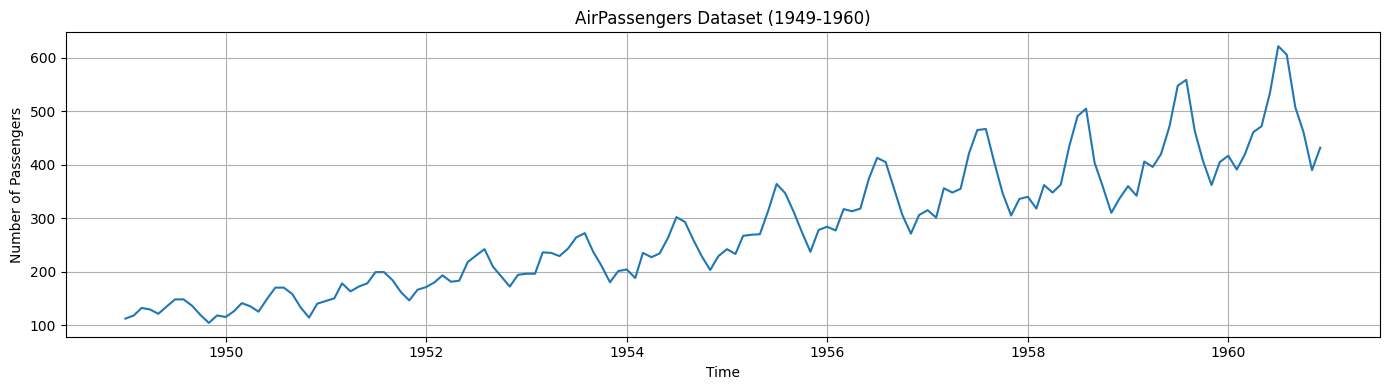

In [7]:
# Visualize the data
fig, ax = get_figure(ncols=1, figsize=(14, 4))
time_plot(x=data.index, y=data['Passengers'],
          title='AirPassengers Dataset (1949-1960)',
          xlabel='Time', ylabel='Number of Passengers', ax=ax[0])
plt.tight_layout()
plt.show()

The AirPassengers dataset shows three clear characteristics:
1. **Strong upward trend**
2. **Annual Seasonal pattern**
3. **Increasing variance over time**

## 1.1 Stationarity Analysis

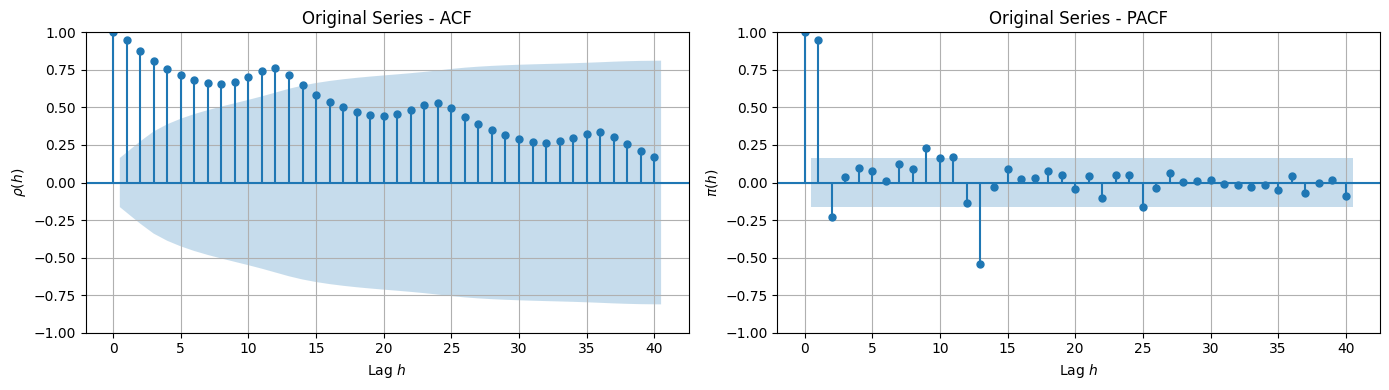

In [8]:
fig, axs = get_figure(ncols=2, figsize=(14, 4))
acf_plot(data['Passengers'], nlags=40, ax=axs[0], title='Original Series - ACF', prefix_title=False)
pacf_plot(data['Passengers'], nlags=40, ax=axs[1], title='Original Series - PACF', prefix_title=False)
plt.tight_layout()
plt.show()

In [9]:
stationarity_tests(data["Passengers"])

Stationarity Test Results:
	- ADF: Non-Stationary (p-value: 0.9919)
	- PP: Non-Stationary (p-value: 0.6055)
	- KPSS: Non-Stationary (p-value: 0.0001)
	- ZA: Non-Stationary (p-value: 0.5808)


The original time series is clearly non-stationary, shown by the strong trend and seasonal pattern visible in the plot. The ACF shows a slow decay typical of non-stationary data with positive trend and seasonality, and the PACF confirms the presence of significant autocorrelation. Statistical tests also reject stationarity, indicating we need transformations before applying certain statistical models.

## 1.2 Making Data Stationary

Applying transformations to achieve stationarity:
- First differencing to remove trend
- Seasonal differencing to remove seasonality (12 months) and variance stabilization

In [10]:
data['Diff'] = data['Passengers'].diff() # First order differencing to remove trend
data['Seasonal'] = data['Passengers'].diff(12) # Seasonal differencing (12 months)
data['Diff_Seasonal'] = data['Passengers'].diff().diff(12) # Combined: first + seasonal differencing (12 months)

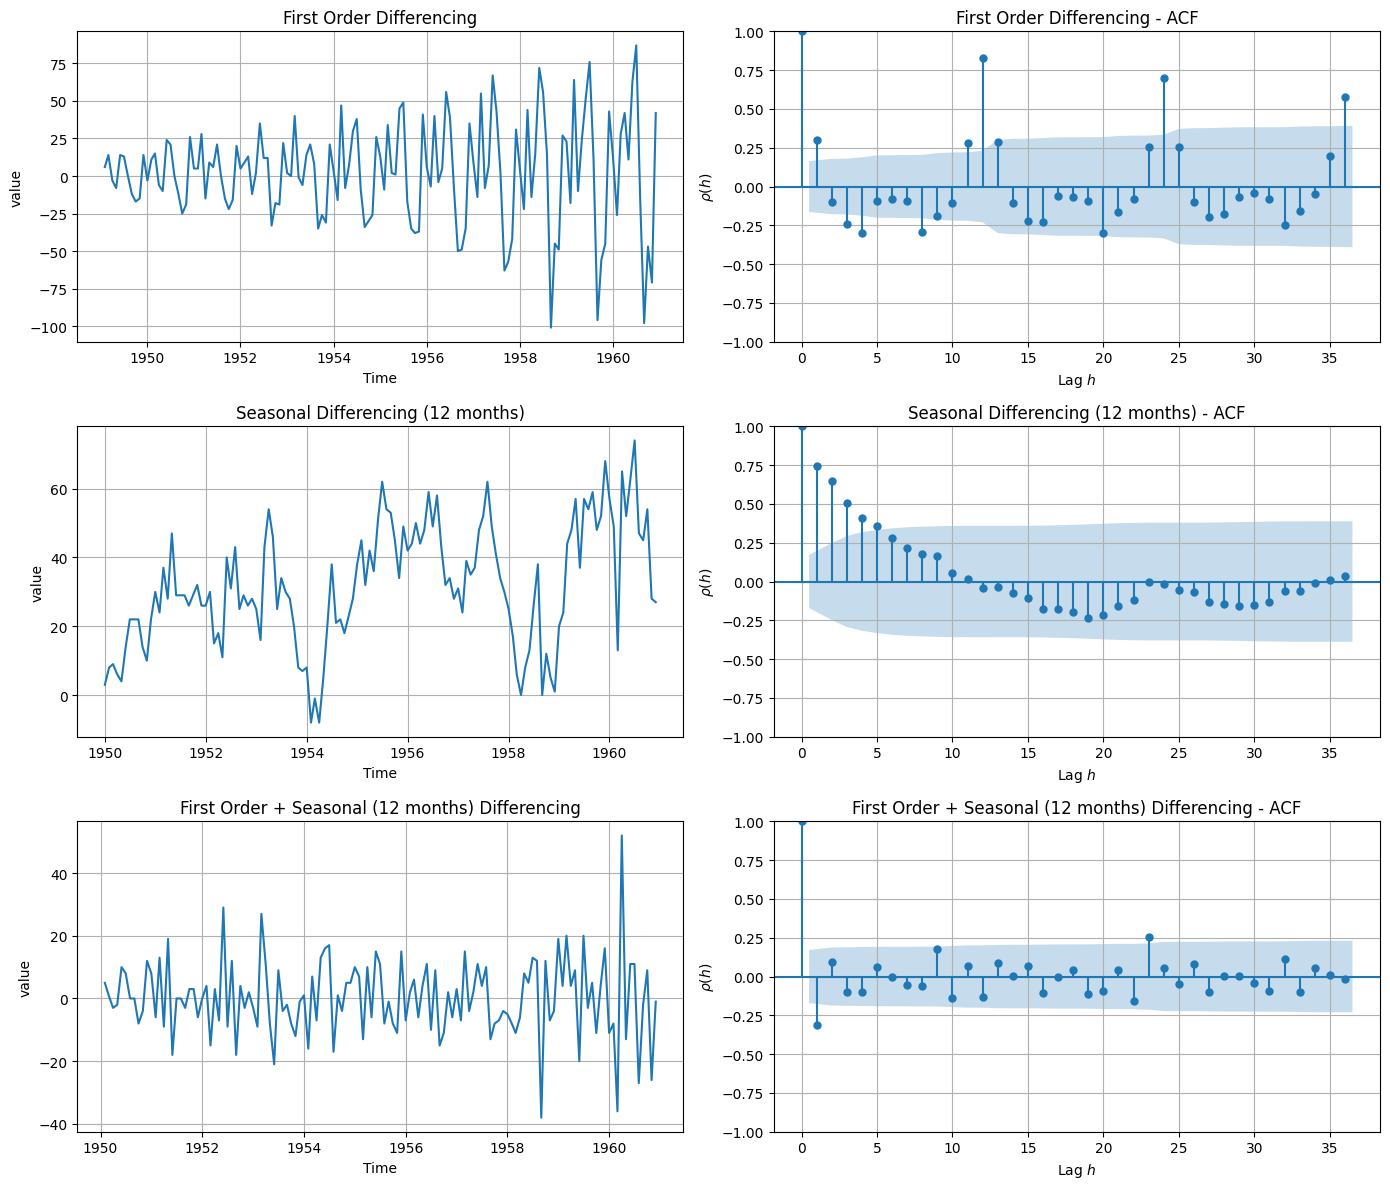

In [11]:
# Visualize transformations
fig, axs = get_figure(nrows=3, ncols=2, figsize=(14, 12))
time_plot(data.index[1:], data['Diff'].dropna(), ax=axs[0], title='First Order Differencing', xlabel='Time', ylabel='value', prefix_title=False)
acf_plot(data['Diff'].dropna(), nlags=len(data)//4, ax=axs[1], title='First Order Differencing - ACF', prefix_title=False)
time_plot(data.index[12:], data['Seasonal'].dropna(), ax=axs[2], title='Seasonal Differencing (12 months)', xlabel='Time', ylabel='value', prefix_title=False)
acf_plot(data['Seasonal'].dropna(), nlags=len(data)//4, ax=axs[3], title='Seasonal Differencing (12 months) - ACF', prefix_title=False)
time_plot(data.index[13:], data['Diff_Seasonal'].dropna(), ax=axs[4], title='First Order + Seasonal (12 months) Differencing', xlabel='Time', ylabel='value', prefix_title=False)
acf_plot(data['Diff_Seasonal'].dropna(), nlags=len(data)//4, ax=axs[5], title='First Order + Seasonal (12 months) Differencing - ACF', prefix_title=False)
plt.tight_layout()
plt.show()

In [12]:
for col in ['Diff', 'Seasonal', 'Diff_Seasonal']:
    print(f"\n{col}:")
    stationarity_tests(data[col].dropna())


Diff:
Stationarity Test Results:
	- ADF: Non-Stationary (p-value: 0.0542)
	- PP: Stationary (p-value: 0.0000)
	- KPSS: Stationary (p-value: 0.9917)
	- ZA: Non-Stationary (p-value: 0.7693)

Seasonal:
Stationarity Test Results:
	- ADF: Stationary (p-value: 0.0116)
	- PP: Stationary (p-value: 0.0002)
	- KPSS: Non-Stationary (p-value: 0.0329)
	- ZA: Non-Stationary (p-value: 0.4136)

Diff_Seasonal:
Stationarity Test Results:
	- ADF: Stationary (p-value: 0.0000)
	- PP: Stationary (p-value: 0.0000)
	- KPSS: Stationary (p-value: 0.8963)
	- ZA: Stationary (p-value: 0.0000)


The transformations successfully achieve stationarity:
- **First differencing** removes the trend but seasonality remains visible in ACF
- **Seasonal differencing (12 months)** removes the yearly seasonal pattern and variance stabilizes
- **Combined differencing** (first order + seasonal) produces stationary results as confirmed by the statistical tests and ACF plots

The combined differenced series also passes the stationarity tests, making it suitable for use as stationary input data

# 3. Deep Learning Models - LSTM & GRU

We implement LSTM and GRU models for time series forecasting. These recurrent neural networks are designed to capture temporal dependencies and patterns in sequential data.

In [13]:
# Configuration parameters
CONFIG = {
    'train_split': 0.8,          # 80-20 train-test split
    'lookback': 12,              # Use 12 months of history
    'horizon': 1,                # Predict 1 month ahead
    'dl_hidden_size': 128,        # Hidden layer size for DL models
    'dl_num_layers': 3,          # Number of LSTM/GRU layers
    'dl_dropout': 0.2,           # Dropout rate
    'dl_epochs': 100,            # Maximum training epochs
    'dl_lr': 1e-3,              # Learning rate
    'dl_batch_size': 8,          # Batch size
    'dl_patience': 15,           # Early stopping patience
    'rf_estimators': 100,        # Random Forest trees
    'gb_estimators': 100,        # Gradient Boosting trees
}

In [14]:
# Create PyTorch Dataset
class TimeSeriesDataset(Dataset):
    """
    PyTorch Dataset for time series data.
    Creates sequences of length 'lookback' to predict 'horizon' steps ahead.
    """
    def __init__(self, data, lookback=12, horizon=1):
        self.data = torch.FloatTensor(data.dropna().values)
        self.lookback = lookback
        self.horizon = horizon

    def __len__(self):
        return len(self.data) - self.lookback - self.horizon + 1

    def __getitem__(self, idx):
        x = self.data[idx:idx+self.lookback]
        y = self.data[idx+self.lookback:idx+self.lookback+self.horizon]
        return x.unsqueeze(-1), y  # Add feature dimension

In [15]:
# LSTM Model
class LSTMModel(L.LightningModule):
    """
    LSTM model for time series forecasting.
    Uses multiple LSTM layers with dropout for regularization.
    """
    def __init__(self, input_size=1, hidden_size=64, num_layers=2, dropout=0.2, horizon=1, lr=0.001):
        super(LSTMModel, self).__init__()
        self.save_hyperparameters()
        self.lstm = nn.LSTM(input_size, hidden_size, num_layers,
                           batch_first=True, dropout=dropout if num_layers > 1 else 0)
        self.fc = nn.Linear(hidden_size, horizon)
        self.criterion = nn.MSELoss()

    def forward(self, x):
        # x shape: (batch, seq_len, input_size)
        lstm_out, _ = self.lstm(x)
        # Take the last time step
        last_output = lstm_out[:, -1, :]
        output = self.fc(last_output)
        return output

    def training_step(self, batch, batch_idx):
        x, y = batch
        y_hat = self(x)
        loss = self.criterion(y_hat, y)
        self.log('train_loss', loss, prog_bar=True, on_step=False, on_epoch=True)
        return loss

    def validation_step(self, batch, batch_idx):
        x, y = batch
        y_hat = self(x)
        loss = self.criterion(y_hat, y)
        self.log('val_loss', loss, prog_bar=True, on_step=False, on_epoch=True)
        return loss

    def configure_optimizers(self):
        optimizer = optim.Adam(self.parameters(), lr=self.hparams.lr)
        scheduler = optim.lr_scheduler.ReduceLROnPlateau(
            optimizer, mode='min', factor=0.5, patience=5, verbose=True
        )
        return {
            'optimizer': optimizer,
            'lr_scheduler': {
                'scheduler': scheduler,
                'monitor': 'val_loss'
            }
        }

In [16]:
# GRU Model
class GRUModel(L.LightningModule):
    """
    GRU model for time series forecasting.
    Similar to LSTM but with simpler gating mechanism.
    """
    def __init__(self, input_size=1, hidden_size=64, num_layers=2, dropout=0.2, horizon=1, lr=0.001):
        super(GRUModel, self).__init__()
        self.save_hyperparameters()
        self.gru = nn.GRU(input_size, hidden_size, num_layers,
                         batch_first=True, dropout=dropout if num_layers > 1 else 0)
        self.fc = nn.Linear(hidden_size, horizon)
        self.criterion = nn.MSELoss()

    def forward(self, x):
        # x shape: (batch, seq_len, input_size)
        gru_out, _ = self.gru(x)
        # Take the last time step
        last_output = gru_out[:, -1, :]
        output = self.fc(last_output)
        return output

    def training_step(self, batch, batch_idx):
        x, y = batch
        y_hat = self(x)
        loss = self.criterion(y_hat, y)
        self.log('train_loss', loss, prog_bar=True, on_step=False, on_epoch=True)
        return loss

    def validation_step(self, batch, batch_idx):
        x, y = batch
        y_hat = self(x)
        loss = self.criterion(y_hat, y)
        self.log('val_loss', loss, prog_bar=True, on_step=False, on_epoch=True)
        return loss

    def configure_optimizers(self):
        optimizer = optim.Adam(self.parameters(), lr=self.hparams.lr)
        scheduler = optim.lr_scheduler.ReduceLROnPlateau(
            optimizer, mode='min', factor=0.5, patience=5, verbose=True
        )
        return {
            'optimizer': optimizer,
            'lr_scheduler': {
                'scheduler': scheduler,
                'monitor': 'val_loss'
            }
        }

In [17]:
# Deep Neural Network (DNN) Model
class DNNModel(L.LightningModule):
    """
    Simple feedforward neural network for time series forecasting.
    Takes the lookback window as a flattened input vector.
    """
    def __init__(self, lookback=12, hidden_size=64, num_layers=3, dropout=0.2, horizon=1, lr=0.001):
        super(DNNModel, self).__init__()
        self.save_hyperparameters()

        layers = []
        input_size = lookback

        for i in range(num_layers):
            layers.append(nn.Linear(input_size, hidden_size))
            layers.append(nn.ReLU())
            if dropout > 0:
                layers.append(nn.Dropout(dropout))
            input_size = hidden_size

        layers.append(nn.Linear(hidden_size, horizon))
        self.network = nn.Sequential(*layers)
        self.criterion = nn.MSELoss()

    def forward(self, x):
        # x shape: (batch, seq_len, input_size)
        # Flatten the sequence dimension
        batch_size = x.size(0)
        x_flat = x.view(batch_size, -1)
        output = self.network(x_flat)
        return output

    def training_step(self, batch, batch_idx):
        x, y = batch
        y_hat = self(x)
        loss = self.criterion(y_hat, y)
        self.log('train_loss', loss, prog_bar=True, on_step=False, on_epoch=True)
        return loss

    def validation_step(self, batch, batch_idx):
        x, y = batch
        y_hat = self(x)
        loss = self.criterion(y_hat, y)
        self.log('val_loss', loss, prog_bar=True, on_step=False, on_epoch=True)
        return loss

    def configure_optimizers(self):
        optimizer = optim.Adam(self.parameters(), lr=self.hparams.lr)
        scheduler = optim.lr_scheduler.ReduceLROnPlateau(
            optimizer, mode='min', factor=0.5, patience=5, verbose=True
        )
        return {
            'optimizer': optimizer,
            'lr_scheduler': {
                'scheduler': scheduler,
                'monitor': 'val_loss'
            }
        }

In [18]:
# Training function using PyTorch Lightning
def train_dl_model(model, train_loader, val_loader, epochs=100, patience=10):
    # Set up callbacks
    early_stop_callback = EarlyStopping(
        monitor='val_loss',
        patience=patience,
        mode='min',
        verbose=True
    )

    # Set up trainer
    trainer = L.Trainer(
        max_epochs=epochs,
        callbacks=[early_stop_callback],
        enable_progress_bar=False,
        enable_model_summary=False,
        logger=True,
        enable_checkpointing=False,
        accelerator='auto',
        devices=1
    )

    # Train the model
    trainer.fit(model, train_loader, val_loader)

    return model

In [19]:
# Prediction function
def predict_dl_model(model, data, lookback=12):
    model.eval()
    predictions = []

    # Determine device from model
    model_device = next(model.parameters()).device

    with torch.no_grad():
        for i in range(len(data) - lookback):
            x = torch.FloatTensor(data[i:i+lookback].values).unsqueeze(0).unsqueeze(-1).to(model_device)
            pred = model(x)
            predictions.append(pred.cpu().numpy()[0, 0])

    return np.array(predictions)

## 3.1 Train DL Models on Original Data

Training LSTM and GRU models on the original (non-stationary) data as a baseline

In [20]:
lookback = CONFIG['lookback']
horizon = CONFIG['horizon']
batch_size = CONFIG['dl_batch_size']

### Train-Test Split

In [21]:
non_stat_data = data['Passengers'].dropna()

In [22]:
# Use 80-20 split
train_size = int(len(non_stat_data) * CONFIG['train_split'])
test_size = len(non_stat_data) - train_size

In [23]:
print(f"\nTrain size: {train_size} observations")
print(f"Test size: {test_size} observations")
print(f"Train period: {non_stat_data.index[0]} to {non_stat_data.index[train_size-1]}")
print(f"Test period: {non_stat_data.index[train_size]} to {non_stat_data.index[-1]}")


Train size: 115 observations
Test size: 29 observations
Train period: 1949-01-01 00:00:00 to 1958-07-01 00:00:00
Test period: 1958-08-01 00:00:00 to 1960-12-01 00:00:00


In [24]:
# Prepare data
train_data_orig = non_stat_data.iloc[:train_size].dropna()
test_data_orig = non_stat_data.iloc[train_size:].dropna()

In [25]:
# Normalize data
scaler_orig = StandardScaler()
train_data_scaled = scaler_orig.fit_transform(train_data_orig.values.reshape(-1, 1)).flatten()
test_data_scaled = scaler_orig.transform(test_data_orig.values.reshape(-1, 1)).flatten()

In [26]:
# Create datasets
full_data_scaled = np.concatenate([train_data_scaled, test_data_scaled])
train_dataset = TimeSeriesDataset(pd.Series(train_data_scaled), lookback, horizon)
val_size = int(len(train_dataset) * 0.2)
train_subset = torch.utils.data.Subset(train_dataset, range(len(train_dataset) - val_size))
val_subset = torch.utils.data.Subset(train_dataset, range(len(train_dataset) - val_size, len(train_dataset)))

In [27]:
train_loader = DataLoader(train_subset, batch_size=batch_size, shuffle=True)
val_loader = DataLoader(val_subset, batch_size=batch_size, shuffle=False)

In [28]:
# Train LSTM on original data
print("\n--- Training LSTM on Original Data ---")
lstm_model_orig = LSTMModel(input_size=1,
                           hidden_size=CONFIG['dl_hidden_size'],
                           num_layers=CONFIG['dl_num_layers'],
                           dropout=CONFIG['dl_dropout'],
                           horizon=horizon,
                           lr=CONFIG['dl_lr'])
lstm_model_orig = train_dl_model(
    lstm_model_orig, train_loader, val_loader,
    epochs=CONFIG['dl_epochs'],
    patience=CONFIG['dl_patience']
)

GPU available: False, used: False



--- Training LSTM on Original Data ---


TPU available: False, using: 0 TPU cores
Metric val_loss improved. New best score: 2.462
Metric val_loss improved by 1.504 >= min_delta = 0.0. New best score: 0.957
Metric val_loss improved by 0.334 >= min_delta = 0.0. New best score: 0.623
Metric val_loss improved by 0.257 >= min_delta = 0.0. New best score: 0.367
Metric val_loss improved by 0.026 >= min_delta = 0.0. New best score: 0.340
Metric val_loss improved by 0.006 >= min_delta = 0.0. New best score: 0.335
Metric val_loss improved by 0.017 >= min_delta = 0.0. New best score: 0.318
Metric val_loss improved by 0.001 >= min_delta = 0.0. New best score: 0.317
Metric val_loss improved by 0.005 >= min_delta = 0.0. New best score: 0.312
Metric val_loss improved by 0.001 >= min_delta = 0.0. New best score: 0.311
Metric val_loss improved by 0.010 >= min_delta = 0.0. New best score: 0.301
Metric val_loss improved by 0.006 >= min_delta = 0.0. New best score: 0.295
Metric val_loss improved by 0.000 >= min_delta = 0.0. New best score: 0.295

In [29]:
# Train GRU on original data
print("\n--- Training GRU on Original Data ---")
gru_model_orig = GRUModel(input_size=1,
                         hidden_size=CONFIG['dl_hidden_size'],
                         num_layers=CONFIG['dl_num_layers'],
                         dropout=CONFIG['dl_dropout'],
                         horizon=horizon,
                         lr=CONFIG['dl_lr'])
gru_model_orig = train_dl_model(
    gru_model_orig, train_loader, val_loader,
    epochs=CONFIG['dl_epochs'],
    patience=CONFIG['dl_patience']
)

GPU available: False, used: False
TPU available: False, using: 0 TPU cores



--- Training GRU on Original Data ---


Metric val_loss improved. New best score: 0.536
Metric val_loss improved by 0.001 >= min_delta = 0.0. New best score: 0.535
Metric val_loss improved by 0.072 >= min_delta = 0.0. New best score: 0.462
Metric val_loss improved by 0.032 >= min_delta = 0.0. New best score: 0.430
Metric val_loss improved by 0.057 >= min_delta = 0.0. New best score: 0.373
Metric val_loss improved by 0.017 >= min_delta = 0.0. New best score: 0.356
Metric val_loss improved by 0.078 >= min_delta = 0.0. New best score: 0.278
Metric val_loss improved by 0.025 >= min_delta = 0.0. New best score: 0.254
Metric val_loss improved by 0.067 >= min_delta = 0.0. New best score: 0.187
Metric val_loss improved by 0.031 >= min_delta = 0.0. New best score: 0.156
Metric val_loss improved by 0.041 >= min_delta = 0.0. New best score: 0.115
Metric val_loss improved by 0.020 >= min_delta = 0.0. New best score: 0.095
Metric val_loss improved by 0.004 >= min_delta = 0.0. New best score: 0.091
Metric val_loss improved by 0.007 >= min

In [30]:
# Train DNN on original data
print("\n--- Training DNN on Original Data ---")
dnn_model_orig = DNNModel(lookback=lookback,
                         hidden_size=CONFIG['dl_hidden_size'],
                         num_layers=CONFIG['dl_num_layers'],
                         dropout=CONFIG['dl_dropout'],
                         horizon=horizon,
                         lr=CONFIG['dl_lr'])
dnn_model_orig = train_dl_model(
    dnn_model_orig, train_loader, val_loader,
    epochs=CONFIG['dl_epochs'],
    patience=CONFIG['dl_patience']
)

GPU available: False, used: False
TPU available: False, using: 0 TPU cores
Metric val_loss improved. New best score: 1.309



--- Training DNN on Original Data ---


Metric val_loss improved by 0.942 >= min_delta = 0.0. New best score: 0.368
Metric val_loss improved by 0.027 >= min_delta = 0.0. New best score: 0.340
Metric val_loss improved by 0.169 >= min_delta = 0.0. New best score: 0.171
Metric val_loss improved by 0.074 >= min_delta = 0.0. New best score: 0.097
Metric val_loss improved by 0.026 >= min_delta = 0.0. New best score: 0.071
Metric val_loss improved by 0.023 >= min_delta = 0.0. New best score: 0.048
Metric val_loss improved by 0.012 >= min_delta = 0.0. New best score: 0.036
Metric val_loss improved by 0.003 >= min_delta = 0.0. New best score: 0.032
Metric val_loss improved by 0.003 >= min_delta = 0.0. New best score: 0.029
Monitored metric val_loss did not improve in the last 15 records. Best score: 0.029. Signaling Trainer to stop.


In [31]:
# Make predictions
lstm_preds_scaled = predict_dl_model(lstm_model_orig, pd.Series(full_data_scaled), lookback)
gru_preds_scaled = predict_dl_model(gru_model_orig, pd.Series(full_data_scaled), lookback)
dnn_preds_scaled = predict_dl_model(dnn_model_orig, pd.Series(full_data_scaled), lookback)

In [32]:
# Inverse transform predictions
lstm_preds_orig = scaler_orig.inverse_transform(lstm_preds_scaled.reshape(-1, 1)).flatten()
gru_preds_orig = scaler_orig.inverse_transform(gru_preds_scaled.reshape(-1, 1)).flatten()
dnn_preds_orig = scaler_orig.inverse_transform(dnn_preds_scaled.reshape(-1, 1)).flatten()

In [33]:
# Evaluate on test set
test_start_idx = train_size - lookback
lstm_test_preds = lstm_preds_orig[test_start_idx:]
gru_test_preds = gru_preds_orig[test_start_idx:]
dnn_test_preds = dnn_preds_orig[test_start_idx:]

In [34]:
lstm_mse_orig = mean_squared_error(test_data_orig, lstm_test_preds)
lstm_mae_orig = mean_absolute_error(test_data_orig, lstm_test_preds)
gru_mse_orig = mean_squared_error(test_data_orig, gru_test_preds)
gru_mae_orig = mean_absolute_error(test_data_orig, gru_test_preds)
dnn_mse_orig = mean_squared_error(test_data_orig, dnn_test_preds)
dnn_mae_orig = mean_absolute_error(test_data_orig, dnn_test_preds)

LSTM - Original Data - MSE: 4981.71, MAE: 50.95
GRU - Original Data - MSE: 5031.15, MAE: 62.37
DNN - Original Data - MSE: 615.64, MAE: 19.67


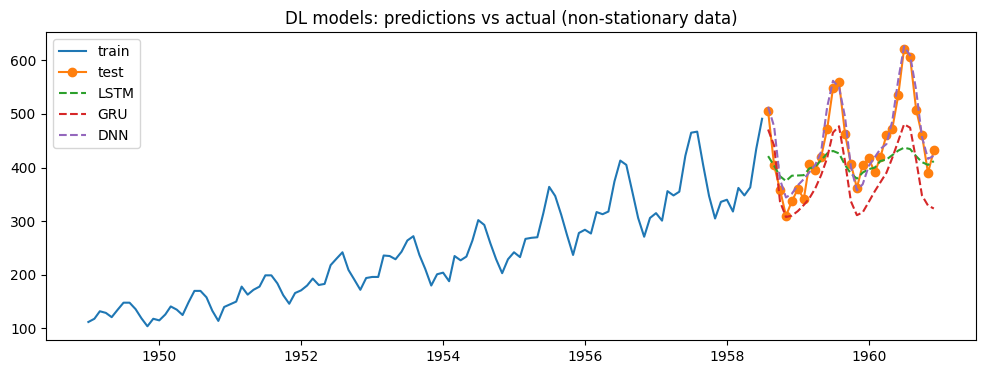

In [35]:
print(f"LSTM - Original Data - MSE: {lstm_mse_orig:.2f}, MAE: {lstm_mae_orig:.2f}")
print(f"GRU - Original Data - MSE: {gru_mse_orig:.2f}, MAE: {gru_mae_orig:.2f}")
print(f"DNN - Original Data - MSE: {dnn_mse_orig:.2f}, MAE: {dnn_mae_orig:.2f}")

fig, ax = plt.subplots(figsize=(12,4))
ax.plot(train_data_orig.index, train_data_orig.values, label='train')
ax.plot(test_data_orig.index, test_data_orig.values, label='test', marker='o')
ax.plot(test_data_orig.index, lstm_test_preds, label='LSTM', linestyle='--')
ax.plot(test_data_orig.index, gru_test_preds, label='GRU', linestyle='--')
ax.plot(test_data_orig.index, dnn_test_preds, label='DNN', linestyle='--')
ax.set_title('DL models: predictions vs actual (non-stationary data)')
ax.legend()
plt.show()

All three models show some ability to learn the most obvious patterns in the data, but performance differs significantly. Although, the LSTM does not perform worst with a MAE of 50.95, it is failing to capture the positive trend and also struggling with seasonality. The GRU gets worse MAE with 62.37, but captures at least the seasonality better. The DNN performs best with a MAE of 19.67, following the test data very closely, capturing both trend and seasonality effectively.

## 3.2 Train DL Models on Stationary Data

In [36]:
stat_data = data['Diff_Seasonal'].dropna()

In [37]:
# Use 80-20 split
train_size = int(len(stat_data) * CONFIG['train_split'])
test_size = len(stat_data) - train_size

In [38]:
print(f"\nTrain size: {train_size} observations")
print(f"Test size: {test_size} observations")
print(f"Train period: {stat_data.index[0]} to {stat_data.index[train_size-1]}")
print(f"Test period: {stat_data.index[train_size]} to {stat_data.index[-1]}")


Train size: 104 observations
Test size: 27 observations
Train period: 1950-02-01 00:00:00 to 1958-09-01 00:00:00
Test period: 1958-10-01 00:00:00 to 1960-12-01 00:00:00


In [39]:
# Use stationary data
train_data_stat = stat_data.iloc[:train_size].dropna()
test_data_stat = stat_data.iloc[train_size:].dropna()

In [40]:
# Normalize
scaler_stat = StandardScaler()
train_data_stat_scaled = scaler_stat.fit_transform(train_data_stat.values.reshape(-1, 1)).flatten()
test_data_stat_scaled = scaler_stat.transform(test_data_stat.values.reshape(-1, 1)).flatten()

In [41]:
# Create datasets
full_data_stat_scaled = np.concatenate([train_data_stat_scaled, test_data_stat_scaled])
train_dataset_stat = TimeSeriesDataset(pd.Series(train_data_stat_scaled), lookback, horizon)
train_subset_stat = torch.utils.data.Subset(train_dataset_stat, range(len(train_dataset_stat) - val_size))
val_subset_stat = torch.utils.data.Subset(train_dataset_stat, range(len(train_dataset_stat) - val_size, len(train_dataset_stat)))

In [42]:
train_loader_stat = DataLoader(train_subset_stat, batch_size=batch_size, shuffle=True)
val_loader_stat = DataLoader(val_subset_stat, batch_size=batch_size, shuffle=False)

In [43]:
# Train LSTM on stationary data
print("\n--- Training LSTM on Stationary Data ---")
lstm_model_stat = LSTMModel(input_size=1,
                          hidden_size=CONFIG['dl_hidden_size'],
                          num_layers=CONFIG['dl_num_layers'],
                          dropout=CONFIG['dl_dropout'],
                          horizon=horizon,
                          lr=CONFIG['dl_lr'])
lstm_model_stat = train_dl_model(
    lstm_model_stat, train_loader_stat, val_loader_stat, epochs=CONFIG['dl_epochs'],
    patience=CONFIG['dl_patience']
)

GPU available: False, used: False
TPU available: False, using: 0 TPU cores



--- Training LSTM on Stationary Data ---


Metric val_loss improved. New best score: 1.318
Metric val_loss improved by 0.004 >= min_delta = 0.0. New best score: 1.314
Metric val_loss improved by 0.001 >= min_delta = 0.0. New best score: 1.313
Metric val_loss improved by 0.013 >= min_delta = 0.0. New best score: 1.300
Metric val_loss improved by 0.009 >= min_delta = 0.0. New best score: 1.291
Metric val_loss improved by 0.010 >= min_delta = 0.0. New best score: 1.281
Metric val_loss improved by 0.031 >= min_delta = 0.0. New best score: 1.250
Metric val_loss improved by 0.025 >= min_delta = 0.0. New best score: 1.225
Metric val_loss improved by 0.031 >= min_delta = 0.0. New best score: 1.194
Monitored metric val_loss did not improve in the last 15 records. Best score: 1.194. Signaling Trainer to stop.


In [44]:
# Train GRU on stationary data
print("\n--- Training GRU on Stationary Data ---")
gru_model_stat = GRUModel(input_size=1,
                        hidden_size=CONFIG['dl_hidden_size'],
                        num_layers=CONFIG['dl_num_layers'],
                        dropout=CONFIG['dl_dropout'],
                        horizon=horizon,
                        lr=CONFIG['dl_lr'])
gru_model_stat = train_dl_model(
    gru_model_stat, train_loader_stat, val_loader_stat, epochs=CONFIG['dl_epochs'],
    patience=CONFIG['dl_patience']
)

GPU available: False, used: False
TPU available: False, using: 0 TPU cores



--- Training GRU on Stationary Data ---


Metric val_loss improved. New best score: 1.299
Metric val_loss improved by 0.015 >= min_delta = 0.0. New best score: 1.284
Metric val_loss improved by 0.015 >= min_delta = 0.0. New best score: 1.269
Metric val_loss improved by 0.004 >= min_delta = 0.0. New best score: 1.265
Metric val_loss improved by 0.000 >= min_delta = 0.0. New best score: 1.265
Monitored metric val_loss did not improve in the last 15 records. Best score: 1.265. Signaling Trainer to stop.


In [45]:
# Train DNN on stationary data
print("\n--- Training DNN on Stationary Data ---")
dnn_model_stat = DNNModel(lookback=lookback,
                         hidden_size=CONFIG['dl_hidden_size'],
                         num_layers=CONFIG['dl_num_layers'],
                         dropout=CONFIG['dl_dropout'],
                         horizon=horizon,
                         lr=CONFIG['dl_lr'])
dnn_model_stat = train_dl_model(
    dnn_model_stat, train_loader_stat, val_loader_stat, epochs=CONFIG['dl_epochs'],
    patience=CONFIG['dl_patience']
)

GPU available: False, used: False
TPU available: False, using: 0 TPU cores



--- Training DNN on Stationary Data ---


Metric val_loss improved. New best score: 1.355
Monitored metric val_loss did not improve in the last 15 records. Best score: 1.355. Signaling Trainer to stop.


In [46]:
# Make predictions and inverse transform
lstm_preds_stat_scaled = predict_dl_model(lstm_model_stat, pd.Series(full_data_stat_scaled), lookback)
gru_preds_stat_scaled = predict_dl_model(gru_model_stat, pd.Series(full_data_stat_scaled), lookback)
dnn_preds_stat_scaled = predict_dl_model(dnn_model_stat, pd.Series(full_data_stat_scaled), lookback)

In [47]:
lstm_preds_stat = scaler_stat.inverse_transform(lstm_preds_stat_scaled.reshape(-1, 1)).flatten()
gru_preds_stat = scaler_stat.inverse_transform(gru_preds_stat_scaled.reshape(-1, 1)).flatten()
dnn_preds_stat = scaler_stat.inverse_transform(dnn_preds_stat_scaled.reshape(-1, 1)).flatten()

In [48]:
# Evaluate on test set
test_start_idx = train_size - lookback
lstm_test_preds = lstm_preds_stat[test_start_idx:]
gru_test_preds = gru_preds_stat[test_start_idx:]
dnn_test_preds = dnn_preds_stat[test_start_idx:]

In [49]:
lstm_mse_stat = mean_squared_error(test_data_stat, lstm_test_preds)
lstm_mae_stat = mean_absolute_error(test_data_stat, lstm_test_preds)
gru_mse_stat = mean_squared_error(test_data_stat, gru_test_preds)
gru_mae_stat = mean_absolute_error(test_data_stat, gru_test_preds)
dnn_mse_stat = mean_squared_error(test_data_stat, dnn_test_preds)
dnn_mae_stat = mean_absolute_error(test_data_stat, dnn_test_preds)

LSTM - Stationary Data - MSE: 345.39, MAE: 14.02
GRU - Stationary Data - MSE: 277.96, MAE: 13.54
DNN - Stationary Data - MSE: 249.62, MAE: 12.13


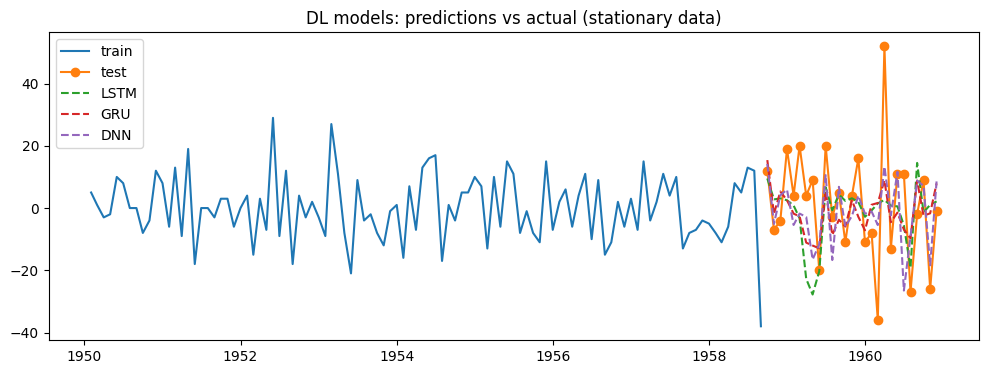

In [50]:
print(f"LSTM - Stationary Data - MSE: {lstm_mse_stat:.2f}, MAE: {lstm_mae_stat:.2f}")
print(f"GRU - Stationary Data - MSE: {gru_mse_stat:.2f}, MAE: {gru_mae_stat:.2f}")
print(f"DNN - Stationary Data - MSE: {dnn_mse_stat:.2f}, MAE: {dnn_mae_stat:.2f}")

fig, ax = plt.subplots(figsize=(12,4))
ax.plot(train_data_stat.index, train_data_stat.values, label='train')
ax.plot(test_data_stat.index, test_data_stat.values, label='test', marker='o')
ax.plot(test_data_stat.index, lstm_test_preds, label='LSTM', linestyle='--')
ax.plot(test_data_stat.index, gru_test_preds, label='GRU', linestyle='--')
ax.plot(test_data_stat.index, dnn_test_preds, label='DNN', linestyle='--')
ax.set_title('DL models: predictions vs actual (stationary data)')
ax.legend()
plt.show()

In absolute terms, the models perform better on the stationary data with MAE's between 12.13 and 14.02, with both LSTM and GRU improving significantly on the original data results. However, the patterns shown in the stationary data were not closely predicted by any of the models, indicating that most of the original data could possibly be captured by statistical methods alone. Again, the DNN model performed best, capturing at least some of the patterns shown in the stationary data, however its MAE of 12.13 is not too far away from the variance of the data itself.

Since the data has been differenced, it is not straightforward to directly compare these results to the original data results. With the patterns in the stationary data being less pronounced, the DL models struggled to capture them effectively. Therefore, the DL models on non-stationary data are preferred for this dataset.

# 4. Machine Learning Models

Training Random Forest and Gradient Boosting models with lag features

In [51]:
# Create lag features
def create_features(data, n_lags=12):
    df = pd.DataFrame({'y': data})
    for i in range(1, n_lags + 1):
        df[f'lag_{i}'] = df['y'].shift(i)
        if i > 1:
            df[f"roll_{i}"] = df['y'].rolling(window=i, min_periods=1, closed='right').mean()
    df = df.dropna()
    X = df.drop('y', axis=1)
    y = df['y']
    return X, y

In [52]:
# Prepare data for ML models
X_train, y_train = create_features(train_data_orig, n_lags=12)
X_test_ml = pd.DataFrame()

In [53]:
# Create test features by rolling through the data
full_series = pd.concat([train_data_orig, test_data_orig])
for i in range(len(test_data_orig)):
    idx = train_size + i
    lags = {}
    for lag in range(1, 13):
        lags[f'lag_{lag}'] = full_series.iloc[idx - lag]
        if lag > 1:
            lags[f'roll_{lag}'] = full_series.iloc[idx - lag:idx].mean()
    X_test_ml = pd.concat([X_test_ml, pd.DataFrame([lags])], ignore_index=True)

In [54]:
print(f"\nTraining set shape: {X_train.shape}")
print(f"Test set shape: {X_test_ml.shape}")


Training set shape: (103, 23)
Test set shape: (29, 23)


In [55]:
# Linear Regression with Lag Features
lr_model = Ridge(alpha=1.0)
lr_model.fit(X_train, y_train)
lr_preds = lr_model.predict(X_test_ml)
lr_mse = mean_squared_error(test_data_orig, lr_preds)
lr_mae = mean_absolute_error(test_data_orig, lr_preds)

In [56]:
# Random Forest
rf_model = RandomForestRegressor(n_estimators=CONFIG['rf_estimators'], max_depth=10, random_state=42, n_jobs=-1)
rf_model.fit(X_train, y_train)
rf_preds = rf_model.predict(X_test_ml)
rf_mse = mean_squared_error(test_data_orig, rf_preds)
rf_mae = mean_absolute_error(test_data_orig, rf_preds)

In [57]:
# Gradient Boosting
gb_model = GradientBoostingRegressor(n_estimators=CONFIG['gb_estimators'], max_depth=5, learning_rate=0.1, random_state=42)
gb_model.fit(X_train, y_train)
gb_preds = gb_model.predict(X_test_ml)
gb_mse = mean_squared_error(test_data_orig, gb_preds)
gb_mae = mean_absolute_error(test_data_orig, gb_preds)

Linear Regression - MSE: 5930.22, MAE: 62.50
Random Forest - MSE: 3416.20, MAE: 47.32
Gradient Boosting - MSE: 3575.82, MAE: 48.90


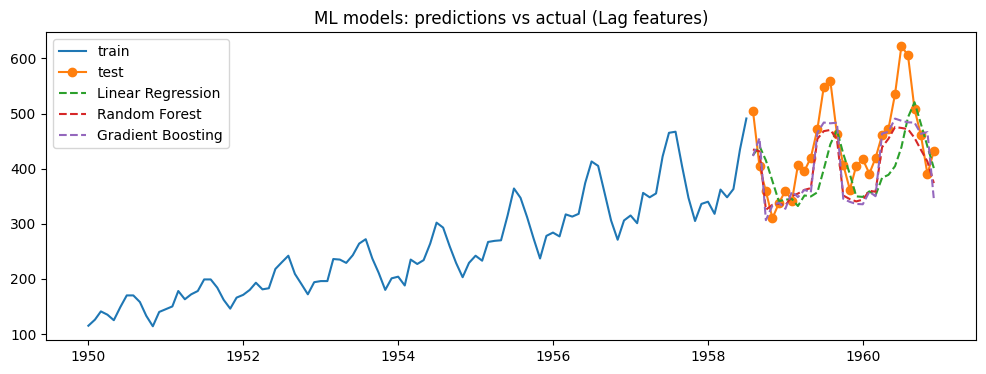

In [58]:
print(f"Linear Regression - MSE: {lr_mse:.2f}, MAE: {lr_mae:.2f}")
print(f"Random Forest - MSE: {rf_mse:.2f}, MAE: {rf_mae:.2f}")
print(f"Gradient Boosting - MSE: {gb_mse:.2f}, MAE: {gb_mae:.2f}")

fig, ax = plt.subplots(figsize=(12,4))
ax.plot(y_train.index, y_train.values, label='train')
ax.plot(test_data_orig.index, test_data_orig.values, label='test', marker='o')
ax.plot(test_data_orig.index, lr_preds, label='Linear Regression', linestyle='--')
ax.plot(test_data_orig.index, rf_preds, label='Random Forest', linestyle='--')
ax.plot(test_data_orig.index, gb_preds, label='Gradient Boosting', linestyle='--')
ax.set_title('ML models: predictions vs actual (Lag features)')
ax.legend()
plt.show()

Both Random Forest and Gradient Boosting models outperformed the Logistic Regression model with MAE's of 47.32 and 48.90 respectively compared to 62.50 for Logistic Regression. All three models were able to capture the trend in the data as well as the seasonality to some extent. For sure missing are the encoded month features which could help the models better capture seasonality. Overall, the ML models performed reasonably well but were outperformed by the simpler statistical models as well as the DNN.

# 5. Statistical Models (ARIMA & ETS)

Training SARIMA and ETS models that explicitly handle seasonality and trend

Based on ACF/PACF analysis and stationarity tests, we'll use SARIMA. The data shows strong seasonality (period=12) and trend.

In [ ]:
sarima = SARIMAX(
    train_data_orig,
    order=(0,1,1),
    seasonal_order=(0,1,1,12),
    enforce_invertibility=False,
    enforce_stationarity=False
)
sarima_res = sarima.fit(disp=False)
sarima_preds = sarima_res.predict(start=test_data_orig.index[0], end=test_data_orig.index[-1])
sarima_mse = mean_squared_error(test_data_orig, sarima_preds)
sarima_mae = mean_absolute_error(test_data_orig, sarima_preds)

In [ ]:
# ETS Model
ets = ExponentialSmoothing(
    train_data_orig,
    trend='add',
    seasonal='mul',
    seasonal_periods=12,
    initialization_method='estimated'
)
ets_fit = ets.fit(optimized=True)
ets_preds = ets_fit.forecast(steps=len(test_data_orig))
ets_mse = mean_squared_error(test_data_orig, ets_preds)
ets_mae = mean_absolute_error(test_data_orig, ets_preds)

SARMIA - MSE: 935.14, MAE: 24.06
ETS - MSE: 678.14, MAE: 21.96


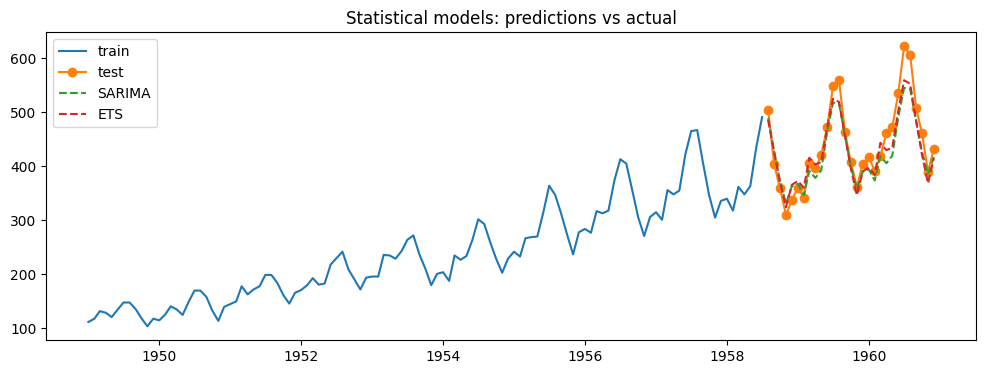

In [61]:
print(f"SARMIA - MSE: {sarima_mse:.2f}, MAE: {sarima_mae:.2f}")
print(f"ETS - MSE: {ets_mse:.2f}, MAE: {ets_mae:.2f}")

fig, ax = plt.subplots(figsize=(12,4))
ax.plot(train_data_orig.index, train_data_orig.values, label='train')
ax.plot(test_data_orig.index, test_data_orig.values, label='test', marker='o')
ax.plot(test_data_orig.index, sarima_preds, label='SARIMA', linestyle='--')
ax.plot(test_data_orig.index, ets_preds, label='ETS', linestyle='--')
ax.set_title('Statistical models: predictions vs actual')
ax.legend()
plt.show()

Both statistical approaches performed very well, with ETS slightly outperforming SARIMA. Both models capture the seasonal pattern as well as the positive trend with similar high accuracy. However, the increase in variance over time is not very well captured by either model, leading to clear underestimation during peak months in later years. Overall, ETS achieved the second-best performance (on non-stationary data) with a MAE of 21.96 only losing out to the DNN model that was able to better capture the increasing variance and therefore predicting the peaks in the data more accurately.